Caricamento e QC iniziale (check obbligatori)

In [1]:

!pip install pycountry-convert


import pycountry_convert as pc

# Standard imports
import os
import sys
from datetime import datetime, timedelta
from tkinter import wantobjects

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')

import warnings

warnings.filterwarnings('ignore')

print('Libraries loaded.')


Libraries loaded.


In [195]:
# Paths
DATA_DIR = r"C:\\Users\\piers\\Desktop\\home\\Sviluppo\\text-llm-learning\\fendi_bc\\Data Scientist Business Case\\data"
CUSTOMERS_PATH = os.path.join(DATA_DIR, 'customers.csv')
TRANSACTIONS_PATH = os.path.join(DATA_DIR, 'transactions.csv')
CAMPAIGNS_PATH = os.path.join(DATA_DIR, 'campaign_tasks.csv')

for p in [CUSTOMERS_PATH, TRANSACTIONS_PATH, CAMPAIGNS_PATH]:
    print(p, 'exists:', os.path.exists(p))

# Costanti:
# optimal snapshot-date:
SNAPSHOT_DATE = '2024-11-11'
REACT_WINDOW = 90
INACTIVITY_DAYS = 120
INACTIVITY_DELTA = timedelta(days=INACTIVITY_DAYS)

CAMPAGNE = ['email', 'letter', 'sms', 'call']
CONTINENT = ["Africa", "Asia", "Europe", "North America", "South America", "Oceania", "Antarctica"]


C:\\Users\\piers\\Desktop\\home\\Sviluppo\\text-llm-learning\\fendi_bc\\Data Scientist Business Case\\data\customers.csv exists: True
C:\\Users\\piers\\Desktop\\home\\Sviluppo\\text-llm-learning\\fendi_bc\\Data Scientist Business Case\\data\transactions.csv exists: True
C:\\Users\\piers\\Desktop\\home\\Sviluppo\\text-llm-learning\\fendi_bc\\Data Scientist Business Case\\data\campaign_tasks.csv exists: True


# 1) Reading Dataset and standardization:

In [3]:
# Utility functions
def parse_dates(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Convert dates columns into pd.to_datetime columns if columns name in cols."""
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors='coerce', utc=True).dt.tz_localize(None)
    return df


def summarize_dataframe(df: pd.DataFrame, name: str) -> None:
    """Just return extra information about dataset (shape, % Null columns, ...)"""
    print(f"\n=== {name} ===")
    print('Shape:', df.shape)
    print('Columns:', list(df.columns))
    print('Null % by column:')
    print((df.isna().mean() * 100).round(2).sort_values(ascending=False).head(20))


def check_required_columns(df: pd.DataFrame, required: list[str], name: str) -> None:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in {name}: {missing}")



In [4]:
# Load datasets
customers = pd.read_csv(CUSTOMERS_PATH)
transactions = pd.read_csv(TRANSACTIONS_PATH)
campaigns = pd.read_csv(CAMPAIGNS_PATH)

# Basic normalization
customers.columns = [c.strip().lower() for c in customers.columns]
transactions.columns = [c.strip().lower() for c in transactions.columns]
campaigns.columns = [c.strip().lower() for c in campaigns.columns]

# # Parse dates cols to datetime:
transactions = parse_dates(transactions, ['event_date'])
campaigns = parse_dates(campaigns, ['start_date', 'end_date', 'last_modified_date'])
customers = parse_dates(customers, ['registration_date'])

summarize_dataframe(customers, 'customers')
summarize_dataframe(transactions, 'transactions')
summarize_dataframe(campaigns, 'campaigns')



=== customers ===
Shape: (3500, 7)
Columns: ['customer_id', 'birth_year', 'gender', 'country', 'registration_date', 'is_active', 'marketing_consent']
Null % by column:
customer_id          0.0
birth_year           0.0
gender               0.0
country              0.0
registration_date    0.0
is_active            0.0
marketing_consent    0.0
dtype: float64

=== transactions ===
Shape: (7000, 6)
Columns: ['customer_id', 'event_type', 'event_date', 'product_category', 'quantity', 'net_sale_euro']
Null % by column:
customer_id         0.0
event_type          0.0
event_date          0.0
product_category    0.0
quantity            0.0
net_sale_euro       0.0
dtype: float64

=== campaigns ===
Shape: (5000, 8)
Columns: ['id_campaign', 'customer_id', 'campaign_status', 'campaign_channel', 'activity_subject', 'start_date', 'end_date', 'last_modified_date']
Null % by column:
id_campaign           0.0
customer_id           0.0
campaign_status       0.0
campaign_channel      0.0
activity_subject  

# Utils:

In [178]:
# funzione per mappare
def alpha2_to_continent(alpha2: str) -> str:
    try:
        continent_code = pc.country_alpha2_to_continent_code(alpha2.upper())
        # converti il codice continente tipo 'EU' in nome completo come "Europe"
        continent_name = pc.convert_continent_code_to_continent_name(continent_code)
        return continent_name
    except Exception as e:
        return 'Unknown'

### 1.1) Check distribution:

<Axes: title={'center': 'Sum € / Day'}, xlabel='event_date'>

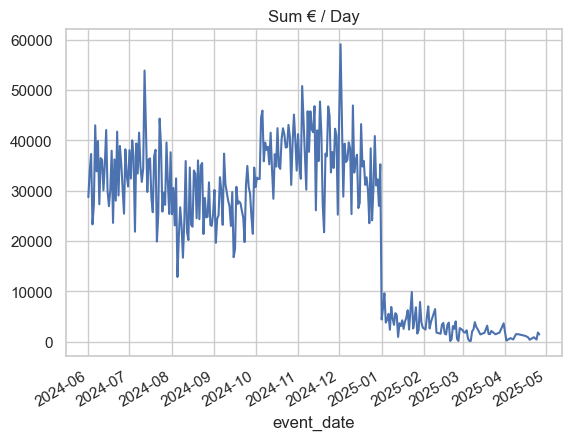

In [5]:
# Distribuzione del spasa netta cumulata per giorno
transactions.groupby('event_date')['net_sale_euro'].sum().plot(title='Sum € / Day')

<Axes: title={'center': 'Distinct client / Day'}, xlabel='event_date'>

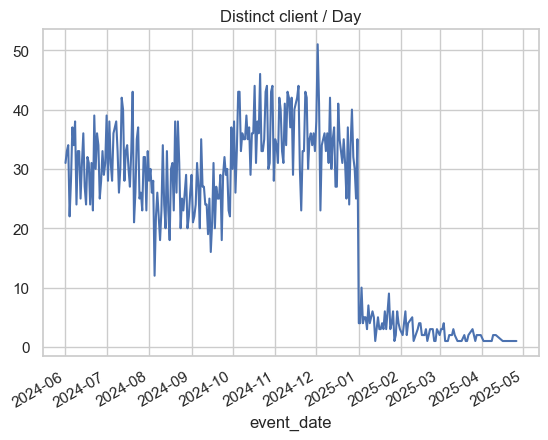

In [6]:
# Distribuzione del numero di utenti per giorno:
(
    transactions.groupby(['event_date', 'customer_id'])['net_sale_euro'].sum()
    .reset_index()
    .groupby('event_date')['customer_id'].count()
).plot(title='Distinct client / Day')

### ALLERT: Qualcosa è successo tra il passaggio il 2024 e il 2025. Buco dati!

# 2) Definizione variabile target, Snapshot-date e Label di riattivazione:

Prima di tutto definisco come etichettare “inattivo” e “riattivato” in modo coerente nel tempo.<br>

Seguo regola di inattività: >120 giorni dall’ultimo acquisto.<br>

Snapshot date (index date): Data di riferimento sulla quale calcolo lo stato di inattività e le feature (es. snapshot = '2024-09-30' o una serie di snapshot retrospettivi per fare backtesting). Perché??? -> Le transactions arrivano fino ad una certa data, quindi per poter osservare la riattivazione nel futuro voglio scegliere uno snapshot abbastanza indietro in modo da avere un “finestra di osservazione” (es. reattivazione entro 90 giorni → snapshot ≤ 2024-10-02).<br>

Label di reattivazione: per ogni cliente inattivo al snapshot, definisco reactivated = 1 se compie almeno un acquisto entro react_window_days dopo lo snapshot (es. 90 giorni), altrimenti 0.<br>

Extra: costruire più snapshot (rolling monthly) per aumentare il dataset di training e test temporale.

In [69]:
# funzione che classifica i clienti inattivi/attivi/reactivated dato uno snapshot, una finestra di reazione e un vincolo di inizio inattività
def reactived_inactive_customers(df_sales, customers, snapshot_date:str, inactivity_days=120, react_window=90):
    snapshot = pd.to_datetime(snapshot_date)
    # ultimo acquisto fino allo snapshot
    df = (
        df_sales[df_sales['event_date'] <= snapshot]
        .groupby('customer_id')['event_date'].max() # ultimo acquisto fatto:
        .reset_index()
        .rename(columns={'event_date':'last_purchase'})
    )
    df = customers.merge(df, on='customer_id', how='left')
    df['days_since_last'] = (snapshot - df['last_purchase']).dt.days
    df['inactive'] = df['days_since_last'] > inactivity_days
    
    # reattivazione nel futuro
    future_end = snapshot + pd.Timedelta(days=react_window)
    future_p = (
        df_sales[(df_sales['event_date'] > snapshot) & (df_sales['event_date'] <= future_end)]
        .groupby('customer_id')['event_date'].min() # prima data utile
        .reset_index()
        .rename(columns={'event_date':'reactivation_date_start'})
    )
    df = df.merge(future_p, on='customer_id', how='left')
    df['reactivated'] = df['inactive'] & df['reactivation_date_start'].notna()
    df['snapshot_date'] = snapshot
    df['react_window'] = react_window
    
    return df



def set_transaction_df(df_transazioni_selezionato):

    case = df_transazioni_selezionato[df_transazioni_selezionato['inactive'] == True].copy()

    case['inactive_date_start'] = case['last_purchase'] + pd.to_timedelta(INACTIVITY_DAYS, unit='d')
    case['date_end_react'] = case['reactivation_date_start'].combine_first(case['snapshot_date'] + pd.to_timedelta(case['react_window'], unit='d'))
    case['inactive_days'] = (case['date_end_react'] - case['inactive_date_start']).dt.days
    case['last_purchase_days'] = (case['date_end_react'] - case['last_purchase']).dt.days

    case = case[[
        'customer_id',
        'last_purchase',  
        'snapshot_date',
        # 'react_window',
        'inactive_date_start', 
        # 'reactivation_date_start',
        'date_end_react',
        'inactive_days',
        'last_purchase_days',
        'is_active',
        'reactivated', 
        'marketing_consent', 
        # 'days_since_last',  
        'gender', 
        'country',
        'age', 
        'registration_date',
    ]]

    return case

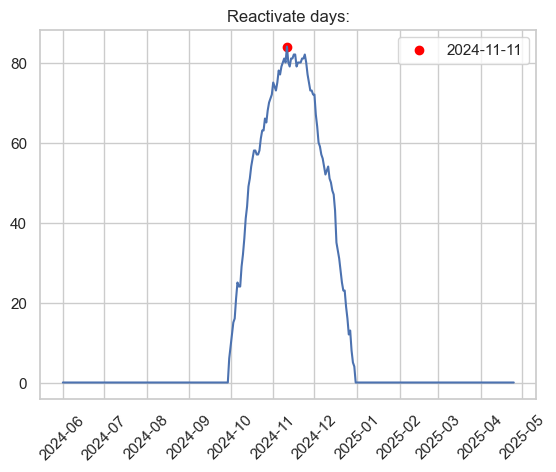

In [41]:
# creo la lista di date tra il massimo e il minimo valore:
day_diff = (transactions['event_date'].max() - transactions['event_date'].min())
base = transactions['event_date'].min()
date_list = [(base + pd.Timedelta(days=x)).strftime('%Y-%m-%d') for x in range(day_diff.days)]


# uso la lista di date per ciclare sulla funzione dei reactived per capire quale snapshot-day è migliore 
# per identificare più utenti che si riattivano:
snapshot_dict = {'snapshot_day':[], 'num_reactivated': []}
for ddt in date_list:
    mk_lab_split = reactived_inactive_customers(transactions, customers, ddt, inactivity_days=INACTIVITY_DAYS, react_window=90)
    snapshot_dict['snapshot_day'].append(pd.to_datetime(ddt))
    snapshot_dict['num_reactivated'].append(mk_lab_split[mk_lab_split['reactivated'] == True].shape[0])


# compongo il plot per rappresentare quale snapshot è meglio raccogliore per selezionare il campione di utenti reactivated più ampio:
reactivate_distribution = pd.DataFrame(snapshot_dict)
max_reactivated = (
    reactivate_distribution[reactivate_distribution['num_reactivated'] == reactivate_distribution['num_reactivated'].max()]
    .set_index('snapshot_day')
)

plt.plot(reactivate_distribution.set_index('snapshot_day'))
plt.scatter(
    max_reactivated.index, 
    max_reactivated.values,
    color='red', 
    label=max_reactivated.index[0].strftime('%Y-%m-%d')
)
plt.legend()
plt.title('Reactivate days:')
plt.xticks(rotation=45)
plt.show()


### Analisi grafico: 
Un fenomeo particolarmente strano (che non mi sarei aspettato di vedere) è osservare come, tra il periodo di ottobre e dicembre 2024, si concentriono tutte le riattivazioni degli utenti. Questo rende l'analisi delle riattivazioni un fenomeno prettamente settoriale e non equidistribuito nel tempo. A questo punto definisco 2 diverse frequenze di rolling per selezionare i miei snapshot:

- low freq. : ogni 30 giorni uno snapshot a partire dall 2024-01-01 fino al 2024-09-30.
- high freq. : ogni 7 giorni uno snapshot a partire dall 2024-10-01 fino al 2024-12-31.

## Lookup Campaign and Transactions - Snapshot method:

In [ ]:
def create_country_lp(df_customers):

    cust = df_customers.copy()
    cust['continent'] = [alpha2_to_continent(x) for x in cust['country']]
    
    NAME_COL = ''
    cust[NAME_COL] = 1
    cust = (
        pd.pivot_table(cust, index=['customer_id'], columns=['continent'], values=[NAME_COL], aggfunc=np.sum)
        .fillna(0)
        .reset_index()
    )

    cust.columns = cust.columns.map(lambda x: "_".join(x) if isinstance(x, tuple) else x)

    # gestisco il caso in cui vengono a mancare dimensioni:
    for col in [NAME_COL + '_' + i for i in CONTINENT]:
        if col not in cust.columns:
            cust[col] = 0

    # cust = cust
    cust.columns = ['customer_id',] + CONTINENT
    return cust
    

# Calcola le campagne effettuare prima dello snapshot temporale:
def campaign_snapshot(df_campaigns, df_snapshot_transiti):

    # seleziono campagne effettive e le colonne d'interesse:
    campaigns_prep = (
        df_campaigns[df_campaigns['campaign_status'] == 'Done'] # NOTE: filtro solo campagne effettive 
        [['customer_id', 'campaign_channel', 'activity_subject', 'start_date', 'end_date']]
    )
    campaigns_prep.columns = ['customer_id', 'campaign_channel', 'activity_subject', 'start_date_camp', 'end_date_camp']
    
    # raccolgo le date precedenti allo snapshot (se utente inattivo) e le date precedenti al nuovo acquisto di riattivazione (riattivo)
    df_cust = df_snapshot_transiti
    df_cust = df_cust.groupby(['customer_id', 'snapshot_date', 'date_end_react'])['reactivated'].count().reset_index().sort_values(['customer_id', 'snapshot_date']).drop('reactivated', axis=1)


    ccp = campaigns_prep.merge(df_cust, on=['customer_id'], how='inner') # solo utenti presenti nella history degli acquisti

    NAME_COL = 'prev_snap'
    ccp[NAME_COL] = 1
    ccp = ccp[ccp['date_end_react'] >= ccp['start_date_camp']]
    ccp = (
        pd.pivot_table(ccp, index=['customer_id', 'snapshot_date'], columns=['campaign_channel'], values=[NAME_COL], aggfunc=np.sum)
        .fillna(0)
        .reset_index()
    )

    ccp.columns = ccp.columns.map(lambda x: "_".join(x) if isinstance(x, tuple) else x)

    # gestisco il caso in cui vengono a mancare dimensioni:
    for col in [NAME_COL + '_' + i for i in CAMPAGNE]:
        if col not in ccp.columns:
            ccp[col] = 0

    # ccp = ccp
    ccp.columns = ['customer_id', 'snapshot_date'] + [NAME_COL + '_' + i for i in CAMPAGNE]
    ccp['tot_campaign'] = ccp.iloc[:,-4:].sum(axis=1)  
    return ccp



# Calcola le campagne effettuare nel periodo di inattività:
def inactive_campaign_snapshot(df_campaigns, df_snapshot_transiti):

    # seleziono campagne effettive e le colonne d'interesse:
    campaigns_prep = (
        df_campaigns[df_campaigns['campaign_status'] == 'Done'] # NOTE: filtro solo campagne effettive 
        [['customer_id', 'campaign_channel', 'activity_subject', 'start_date', 'end_date']]
    )
    campaigns_prep.columns = ['customer_id', 'campaign_channel', 'activity_subject', 'start_date_camp', 'end_date_camp']
    
    # raccolgo le date precedenti allo snapshot (se utente inattivo) e le date precedenti al nuovo acquisto di riattivazione (riattivo)
    df_cust = df_snapshot_transiti
    df_cust = df_cust.groupby(['customer_id', 'snapshot_date', 'inactive_date_start','date_end_react'])['reactivated'].count().reset_index().sort_values(['customer_id', 'snapshot_date']).drop('reactivated', axis=1)


    ccp = campaigns_prep.merge(df_cust, on=['customer_id'], how='inner') # solo utenti presenti nella history degli acquisti

    NAME_COL = 'inactive'
    ccp[NAME_COL] = 1

    # NOTE: seleziono solo il periodo di inattività fino al termine della finestra di date_end_react (data di riattivazione o termine finestra temporale di reazione):
    ccp = ccp[
        # NOTE: la campagna deve essere fatta nel periodo a partire dalla data di inattività_
        (ccp['date_end_react'] >= ccp['start_date_camp']) 
        &
        (ccp['start_date_camp'] > ccp['inactive_date_start']) 
    ]

    ccp = (
        pd.pivot_table(ccp, index=['customer_id', 'snapshot_date'], columns=['campaign_channel'], values=[NAME_COL], aggfunc=np.sum)
        .fillna(0)
        .reset_index()
    )
    ccp.columns = ccp.columns.map(lambda x: "_".join(x) if isinstance(x, tuple) else x)

    # gestisco il caso in cui vengono a mancare dimensioni:
    for col in [NAME_COL + '_' + i for i in CAMPAGNE]:
        if col not in ccp.columns:
            ccp[col] = 0

    # ccp = ccp
    ccp.columns = ['customer_id', 'snapshot_date'] + [NAME_COL + '_' + i for i in CAMPAGNE]
    ccp['inactive_tot_campaign'] = ccp.iloc[:,-4:].sum(axis=1)  
    return ccp


def transaction_snapshot(df_transactions, df_snapshot_transiti):

    # seleziono campagne effettive e le colonne d'interesse:
    transaction_prep = df_transactions[['customer_id', 'event_date', 'product_category', 'quantity', 'net_sale_euro']]
    transaction_prep['u_price'] = transaction_prep['net_sale_euro'] / transaction_prep['quantity']
    
    # raccolgo le date precedenti allo snapshot (se utente inattivo) e le date precedenti al nuovo acquisto di riattivazione (riattivo)
    df_cust = df_snapshot_transiti
    df_cust = (
        df_cust
        .groupby(['customer_id', 'snapshot_date', 'date_end_react'])
        ['reactivated'].count()
        .reset_index()
        .sort_values(['customer_id', 'snapshot_date'])
        .drop('reactivated', axis=1)
    )


    ccp = transaction_prep.merge(df_cust, on=['customer_id'], how='inner') # solo utenti presenti nella history degli acquisti
    ccp['vals'] = 1
    ccp = ccp[ccp['date_end_react'] >= ccp['event_date']]
    
    # report generale
    ccp_general = (
        ccp
        .groupby(['customer_id', 'snapshot_date'])
        .agg({
            'vals': 'sum',
            'quantity': ['sum', 'mean'],
            'net_sale_euro': ['sum'],
            'u_price': ['mean']
        })
        .reset_index()
        .rename(columns={'vals': 'n_day_acq'})
    )
    ccp_general.columns = [f"{i[0]}_{i[1]}" if len(i) > 1 and i[1] else i[0] for i in ccp_general.columns]
    ccp_general = ccp_general.rename(columns={'n_day_acq_sum': 'n_day_acq'})
    
    # report sul dettaglio prodotto acquistato:
    ccp_detailed = pd.pivot_table(
        ccp,
        values=['quantity', 'net_sale_euro'],
        index=['customer_id', 'snapshot_date'],
        columns='product_category',
        aggfunc={'quantity':'sum', 'net_sale_euro':'sum'},
        fill_value=0
    ).reset_index().sort_values(['customer_id', 'snapshot_date'])

    ccp_detailed.columns = [f"{i[0]}_{i[1]}" if len(i) > 1 and i[1] else i[0] for i in ccp_detailed.columns]

    return ccp_general, ccp_detailed

# Dataset di Analisi - Composizione:

In [ ]:
# Preparo la lista degli snapshots:
start = pd.to_datetime("2024-01-01")
end   = pd.to_datetime("2024-12-31")

# mensile fuori dal picco
snapshots_low = pd.date_range(start, "2024-09-30", freq="30D")

# settimanale dentro al picco
snapshots_peak = pd.date_range("2024-10-01", end, freq="7D")

# unisco gli snapshot in una unica lista:
snapshots = snapshots_low.union(snapshots_peak)

############################################################

# Creo gli snapshot
labels_list = [
    reactived_inactive_customers(
        df_sales=transactions, 
        customers=customers,
        snapshot_date=s, 
        inactivity_days=INACTIVITY_DAYS, 
        react_window=REACT_WINDOW
    ) 
    for s in snapshots
]

all_labels = pd.concat(labels_list).sort_values(['snapshot_date','customer_id']).reset_index(drop=True)
all_labels['age'] = pd.to_datetime("today").year - all_labels['birth_year']
all_labels = all_labels.drop('birth_year', axis=1)

# Select only inactive and reactivated customers
df_select = all_labels[all_labels['inactive'] == True]

# organizzo meglio il dataset selezionato
df_select = set_transaction_df(df_select)

print(df_select.shape)
df_select.head()


(4756, 14)


,customer_id,last_purchase,snapshot_date,inactive_date_start,date_end_react,inactive_days,last_purchase_days,is_active,reactivated,marketing_consent,gender,country,age,registration_date
35210,CUST_00211,2024-06-01,2024-10-01,2024-09-29,2024-10-30,31,151,1,True,1,F,CN,37,2024-12-31
35623,CUST_00624,2024-06-02,2024-10-01,2024-09-30,2024-12-30,91,211,0,False,1,M,CN,47,2023-08-10
35688,CUST_00689,2024-06-01,2024-10-01,2024-09-29,2024-12-17,79,199,1,True,1,M,CN,29,2024-05-20
35774,CUST_00775,2024-06-02,2024-10-01,2024-09-30,2024-10-16,16,136,1,True,1,F,DE,51,2024-04-27
35856,CUST_00857,2024-06-02,2024-10-01,2024-09-30,2024-12-30,91,211,0,False,1,F,JP,21,2023-10-03


In [ ]:
# calcolo le lookup delle campagne effettuate prima della riattivazione o prima dello snapshot
campaigns_lp = campaign_snapshot(campaigns, df_select)
inactive_campaigns_lp = inactive_campaign_snapshot(campaigns, df_select)
country_lp = create_country_lp(customers)

# calcolo le look delle azioni di acquisti effettuati prima della riattivazione o prima dello snapshot
trans_general_lp, trans_prod_det_lp = transaction_snapshot(transactions, df_select)

# prendo le lookup calcolate (campagne general, transazioni generali e transizioni per prodotto per ogni utente) e vado in join con la tabella di analysi:
df_analysis = (
    df_select
    .merge(campaigns_lp, on=['customer_id', 'snapshot_date'], how='left')
    .merge(inactive_campaigns_lp, on=['customer_id', 'snapshot_date'], how='left')
    .merge(trans_general_lp, on=['customer_id', 'snapshot_date'], how='left')
    .merge(trans_prod_det_lp, on=['customer_id', 'snapshot_date'], how='left')
    .merge(country_lp, on=['customer_id'], how='left')
)

# Riduco la complessità (bias delle nazioni mancanti) convertendo l'alpha2code in continente:
df_analysis['continent'] = [alpha2_to_continent(x) for x in df_analysis['country']]

# le variabili di campaign (call, email, letter, sms, tot_campaign) possono essere nulle. Sostituzione valori mancanti con 0:
fillna_values = {
    "prev_snap_call": 0, 
    "prev_snap_email": 0, 
    "prev_snap_letter": 0, 
    "prev_snap_sms": 0, 
    "tot_campaign": 0,
    "inactive_call": 0, 
    "inactive_email": 0, 
    "inactive_letter": 0, 
    "inactive_sms": 0, 
    "inactive_tot_campaign": 0
}
df_analysis = df_analysis.fillna(value=fillna_values)

df_analysis = df_analysis[[
    'customer_id', 
    'last_purchase', 
    'snapshot_date', 
    'inactive_date_start', 
    'date_end_react', 
    'inactive_days', 
    'last_purchase_days', 
    'is_active',
    'reactivated', 
    'marketing_consent', 
    # 'registration_date', 
    'prev_snap_email', 
    'prev_snap_letter', 
    'prev_snap_sms',
    'prev_snap_call', 
    'tot_campaign', 
    'inactive_email', 
    'inactive_letter', 
    'inactive_sms', 
    'inactive_call', 
    'inactive_tot_campaign', 
    'n_day_acq',
    'quantity_sum', 
    'quantity_mean', 
    'net_sale_euro_sum', 
    'u_price_mean', 
    'net_sale_euro_bags', 
    'net_sale_euro_rtw', 
    'net_sale_euro_shoes',
    'net_sale_euro_slg', 
    'net_sale_euro_textile', 
    'quantity_bags', 
    'quantity_rtw', 
    'quantity_shoes', 
    'quantity_slg', 
    'quantity_textile',
    'gender', 
    # 'country', 
    'age',  
    'Africa',
    'Asia',
    'Europe', 
    'North America', 
    'South America', 
    'Oceania', 
    'Antarctica', 
    'continent'
]]

print(df_analysis.shape)
print(df_analysis.reactivated.value_counts())
print(df_analysis.reactivated.value_counts() / df_analysis.shape[0])

df_analysis.head()

(4756, 45)
reactivated
False    4058
True      698
Name: count, dtype: int64
reactivated
False    0.853238
True     0.146762
Name: count, dtype: float64


,customer_id,last_purchase,snapshot_date,inactive_date_start,date_end_react,inactive_days,last_purchase_days,is_active,reactivated,marketing_consent,prev_snap_email,prev_snap_letter,prev_snap_sms,prev_snap_call,tot_campaign,inactive_email,inactive_letter,inactive_sms,inactive_call,inactive_tot_campaign,n_day_acq,quantity_sum,quantity_mean,net_sale_euro_sum,u_price_mean,net_sale_euro_bags,net_sale_euro_rtw,net_sale_euro_shoes,net_sale_euro_slg,net_sale_euro_textile,quantity_bags,quantity_rtw,quantity_shoes,quantity_slg,quantity_textile,gender,age,Africa,Asia,Europe,North America,South America,Oceania,Antarctica,continent
0,CUST_00211,2024-06-01,2024-10-01,2024-09-29,2024-10-30,31,151,1,True,1,0.0,0.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,2,5,2.5,1160.99,330.5350,0.00,494.43,0.00,666.56,0.00,0,1,0,4,0,F,37,1.0,0.0,0.0,0,0,0,0,Asia
1,CUST_00624,2024-06-02,2024-10-01,2024-09-30,2024-12-30,91,211,0,False,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2,2.0,1458.08,729.0400,0.00,0.00,0.00,0.00,1458.08,0,0,0,0,2,M,47,1.0,0.0,0.0,0,0,0,0,Asia
2,CUST_00689,2024-06-01,2024-10-01,2024-09-29,2024-12-17,79,199,1,True,1,0.0,1.0,1.0,0.0,2.0,0.0,0.0,1.0,0.0,1.0,2,5,2.5,2422.41,561.9525,0.00,0.00,523.80,1898.61,0.00,0,0,3,2,0,M,29,1.0,0.0,0.0,0,0,0,0,Asia
3,CUST_00775,2024-06-02,2024-10-01,2024-09-30,2024-10-16,16,136,1,True,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,3,1.5,1803.91,796.4900,421.86,1382.05,0.00,0.00,0.00,2,1,0,0,0,F,51,0.0,1.0,0.0,0,0,0,0,Europe
4,CUST_00857,2024-06-02,2024-10-01,2024-09-30,2024-12-30,91,211,0,False,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2,2.0,489.29,244.6450,0.00,0.00,489.29,0.00,0.00,0,0,2,0,0,F,21,1.0,0.0,0.0,0,0,0,0,Asia


In [198]:
df_analysis.to_csv(os.path.join(DATA_DIR, 'fe_model_dataset.csv'), index=False)